In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv("Churn_Modelling.csv")

# EDA

In [37]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
df.drop(
    ["RowNumber" , "CustomerId" , "Surname"], 
    axis=1 , inplace=True
)

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [40]:
df.duplicated().sum().item()

0

In [41]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [42]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [43]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [44]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [45]:
print((df['Balance'] == 0).mean())

0.3617


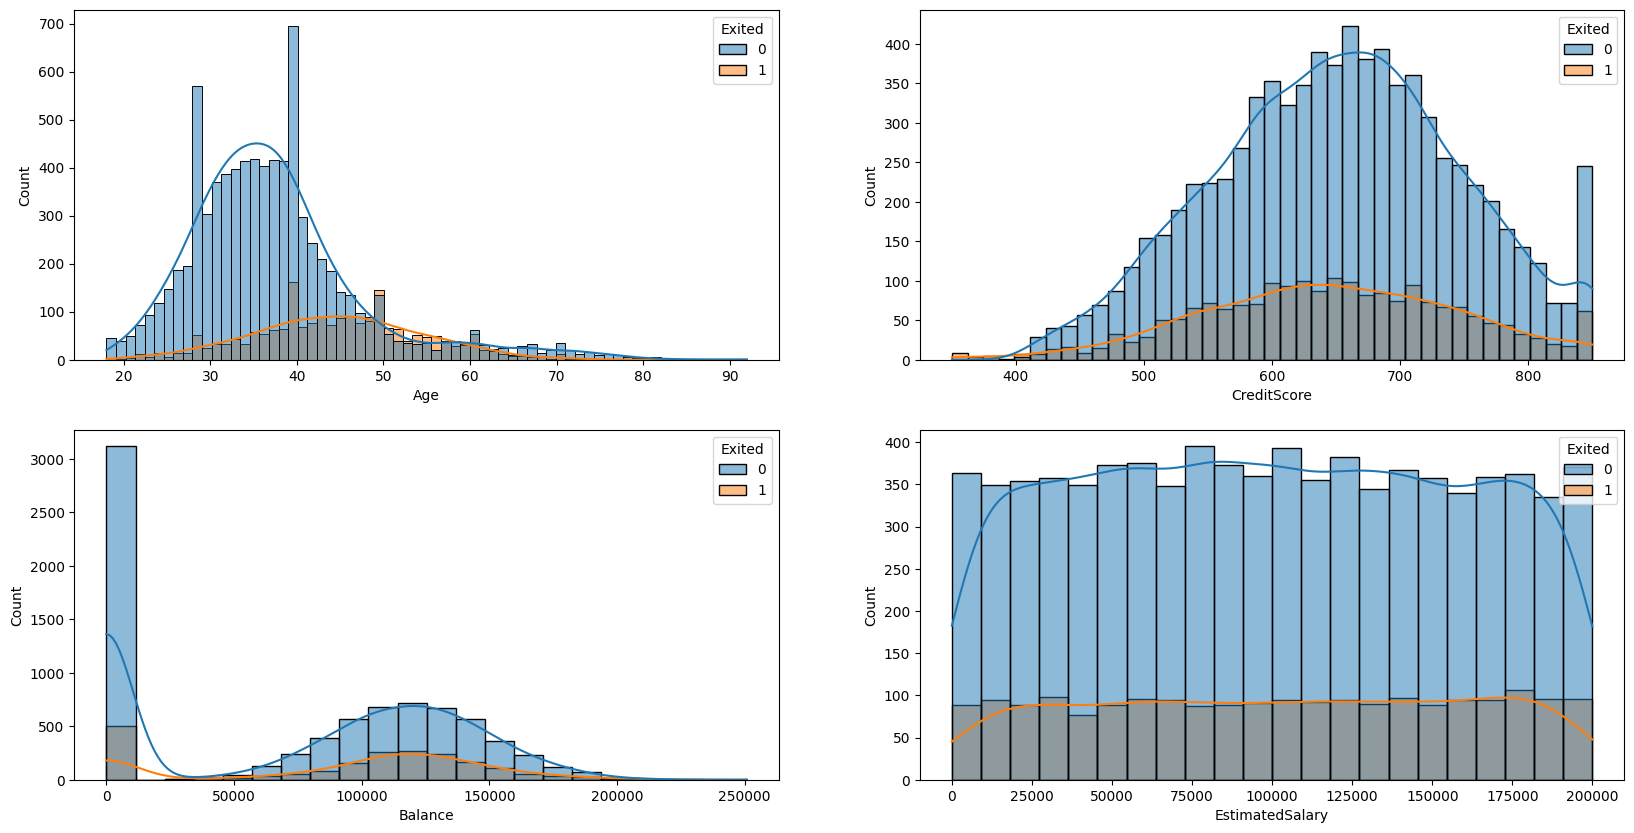

In [46]:
fig , axes = plt.subplots(2 , 2 , figsize=(20 , 10))

sns.histplot(
    data = df,
    x = "Age",
    kde = True,
    hue = "Exited",
    ax = axes[0,0]
)

sns.histplot(
    data = df ,
    x = "CreditScore",
    kde = True,
    hue = "Exited",
    ax = axes[0,1]
)

sns.histplot(
    data = df,
    x = "Balance",
    kde = True,
    hue = "Exited",
    ax = axes[1,0]
)

sns.histplot(
    data = df,
    x = "EstimatedSalary",
    kde = True,
    hue = "Exited",
    ax = axes[1,1]
)

plt.show()


In [47]:
print(df.groupby('Geography')['Exited'].mean() , "\n")
print(df.groupby('Gender')['Exited'].mean() , "\n")
print(df.groupby('NumOfProducts')['Exited'].mean() , "\n")
print(df.groupby('IsActiveMember')['Exited'].mean() , "\n")

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64 

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64 

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64 

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64 



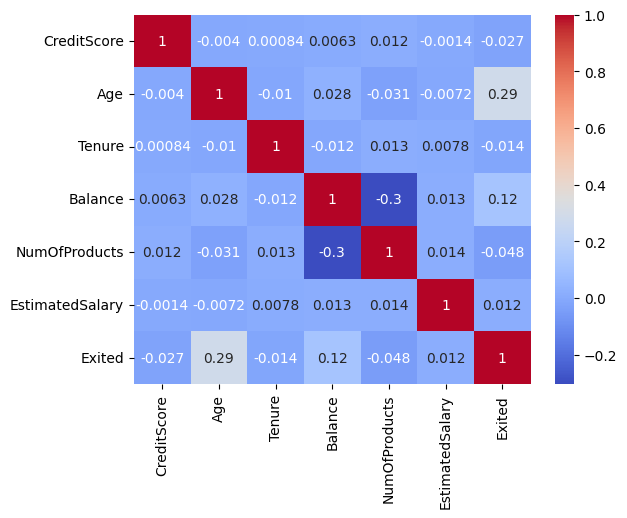

In [48]:
num_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
sns.heatmap(df[num_cols + ['Exited']].corr(), annot=True, cmap='coolwarm')
plt.show()

# Feature Engineering

In [49]:
df["NonZeroBalance"] = (df["Balance"] != 0).astype(int)

In [50]:
# balance to salary ratio - financial engagement ka relative measure
df['balance_salary_ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)  # +1 taaki divide by zero na ho

In [51]:
# age binning - churn behavior often non-linear with age, banking domain me
# young/middle/senior categories alag risk profile rakhte hain
df['age_group'] = pd.cut(df['Age'], bins=[18, 30, 45, 60, 100], labels=['young','adult','middle_age','senior'])


In [52]:
# tenure to age ratio - kitne fraction of adult life customer bank ke saath raha
df['tenure_age_ratio'] = df['Tenure'] / df['Age']

In [53]:
# products per tenure year - engagement rate
df['products_per_tenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

In [54]:
# interaction: inactive + has multiple products (potential over-served but disengaged customer)
df['inactive_multi_product'] = ((df['IsActiveMember']==0) & (df['NumOfProducts']>2)).astype(int)

### One-Hot-Encodeing

In [55]:
df = pd.get_dummies(
    df,
    columns = ["Gender" , "Geography" , "age_group"],
    drop_first = True
)

In [56]:
from sklearn.model_selection import train_test_split

X = df.drop("Exited" , axis=1)
y = df["Exited"]

X_train , X_test , y_train , y_test = train_test_split(
    X , y ,
    test_size = 0.3,
    stratify = y,
    random_state = 42
)

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

pipe_scale = Pipeline([
    ("std" , StandardScaler())
])

tr = ColumnTransformer([
    ["standard_Scaler" , pipe_scale , ["Age" , "CreditScore" , "Balance" , "EstimatedSalary"]]
],remainder="passthrough")

X_train_processed = tr.fit_transform(X_train)
X_test_processed = tr.transform(X_test)

X_train_processed = X_train_processed.astype('float32')
X_test_processed = X_test_processed.astype('float32')

# Artifical Neural Network (ANN)

In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import layers

In [59]:
ANN = keras.Sequential([

    layers.Input(
        shape=(19,)
    ),

    layers.Dense(
        11 , activation='relu'
    ),
    layers.Dropout(0.2),

    layers.Dense(
        8, activation='relu'
    ),

    layers.Dense(
        1, activation='sigmoid'
    )
])

ANN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325 (1.27 KB)

 Trainable params: 325 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
ANN.compile(
    loss = "binary_crossentropy",
    optimizer = keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

In [61]:
history = ANN.fit(
    X_train_processed , y_train,
    epochs = 100,
    validation_split = 0.2,
    batch_size = 32,
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor = 'val_loss', # Track Validation loss after each epoch
            patience = 5, # stop training is after 5 concusitive epoch val_score not improve
            restore_best_weights = True # after every epoch stores best weights where val_loss was lowest
        )
    ]
)

Epoch 1/100


175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7937 - loss: 0.5214 - precision_1: 0.3077 - recall_1: 0.0141 - val_accuracy: 0.7793 - val_loss: 0.4797 - val_precision_1: 0.3902 - val_recall_1: 0.1100
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7954 - loss: 0.4520 - precision_1: 0.3778 - recall_1: 0.0150 - val_accuracy: 0.8157 - val_loss: 0.5035 - val_precision_1: 0.6410 - val_recall_1: 0.2577
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8184 - loss: 0.4354 - precision_1: 0.6359 - recall_1: 0.2432 - val_accuracy: 0.8400 - val_loss: 0.4400 - val_precision_1: 0.8681 - val_recall_1: 0.2715
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8204 - loss: 0.4195 - precision_1: 0.6650 - recall_1: 0.2291 - val_accuracy: 0.8393 - val_loss: 0.4052 - val_precision_1: 0.8667 - val_recall_1: 0.2680
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8250 - loss: 0.4223 - precision_1: 0.6703 - recall_1: 0.2687 - val_ac

#### Pytorch implementation

In [62]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset , DataLoader
import copy

X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_ds = TensorDataset(X_train_tensor , y_train_tensor)
train_loader = DataLoader(train_ds , batch_size=32 , shuffle=True)

class ArtificialNeuralNetwork(nn.Module):

    def __init__(self , input_dim):

        super().__init__()

        self.fc1 = nn.Linear(input_dim , 11)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(11 , 8)
        self.fc3 = nn.Linear(8 , 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self , x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

model = ArtificialNeuralNetwork(input_dim = 19)


criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters() , lr=0.01)

epochs = 1000
patience = 5
best_val_loss = float('inf')
paitence_counter = 0
best_weights = None

for epoch in range(epochs):

    model.train()
    train_loss = 0.0

    for X_batch , y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

        # --- validation ---
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_tensor)
        val_loss = criterion(val_pred, y_test_tensor).item()

    print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

    # --- early stopping check ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

model.load_state_dict(best_weights)




Epoch 1/1000 - train_loss: 0.4688 - val_loss: 0.4090
Epoch 2/1000 - train_loss: 0.4387 - val_loss: 0.4120
Epoch 3/1000 - train_loss: 0.4274 - val_loss: 0.4199
Epoch 4/1000 - train_loss: 0.4183 - val_loss: 0.3892
Epoch 5/1000 - train_loss: 0.4276 - val_loss: 0.4285
Epoch 6/1000 - train_loss: 0.4179 - val_loss: 0.4005
Epoch 7/1000 - train_loss: 0.4078 - val_loss: 0.4044
Epoch 8/1000 - train_loss: 0.4282 - val_loss: 0.4087
Epoch 9/1000 - train_loss: 0.4292 - val_loss: 0.4087
Early stopping triggered at epoch 9


<All keys matched successfully>

In [63]:
model.eval()
with torch.no_grad():
    y_test_proba = model(X_test_tensor)
    y_test_pred = (y_test_proba > 0.5).float()
    accuracy = (y_test_pred == y_test_tensor).float().mean()
    print(f"\nTest Accuracy: {accuracy.item():.4f}")

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test_tensor.numpy(), y_test_pred.numpy()))
print(classification_report(y_test_tensor.numpy(), y_test_pred.numpy()))


Test Accuracy: 0.8433
[[2326   63]
 [ 407  204]]
              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91      2389
         1.0       0.76      0.33      0.46       611

    accuracy                           0.84      3000
   macro avg       0.81      0.65      0.69      3000
weighted avg       0.83      0.84      0.82      3000



In [64]:
print(
    np.mean(history.history["accuracy"]).round(3)
)

0.829


#### Loss Curve : Training Loss Vs Validation Loss

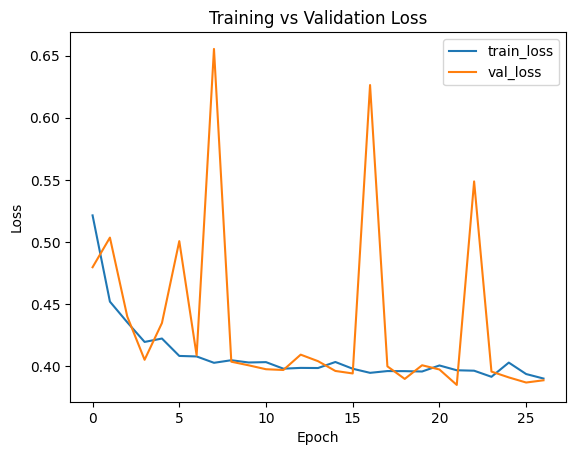

In [65]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

#### Accuracy curve (train vs validation)

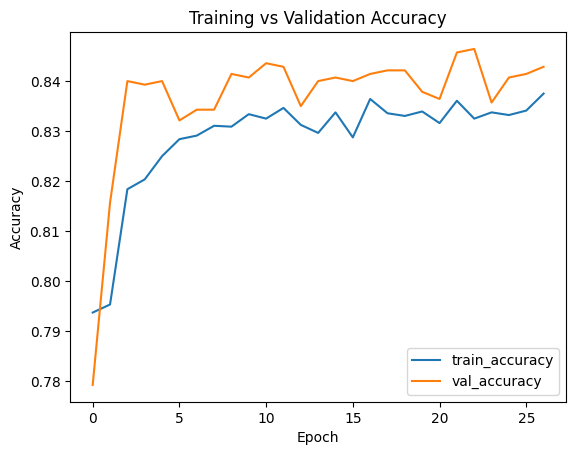

In [66]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

#### Precision aur Recall curve

In [67]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'precision_1', 'recall_1', 'val_accuracy', 'val_loss', 'val_precision_1', 'val_recall_1'])


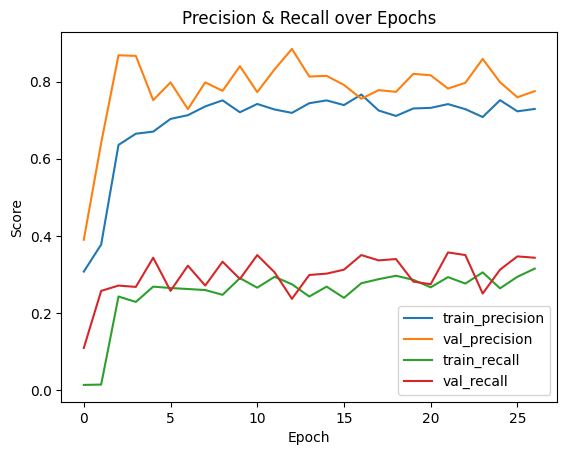

In [68]:
plt.plot(history.history['precision_1'], label='train_precision')
plt.plot(history.history['val_precision_1'], label='val_precision')
plt.plot(history.history['recall_1'], label='train_recall')
plt.plot(history.history['val_recall_1'], label='val_recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Precision & Recall over Epochs')
plt.legend()
plt.show()

#### Confusion Matrix (on test set , after predictions)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step


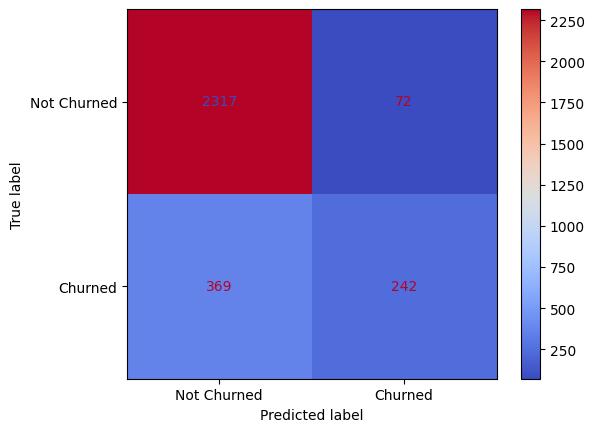

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = (ANN.predict(X_test_processed) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned', 'Churned'])
disp.plot(cmap='coolwarm')
plt.show()

#### ROC Curve + AUC

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step


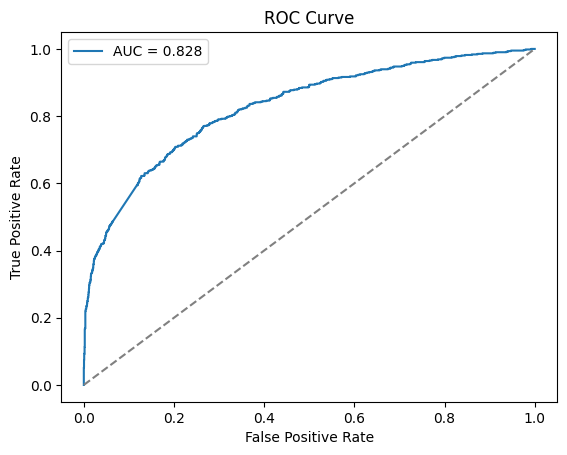

In [70]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = ANN.predict(X_test_processed).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

#### Precision-Recall Curve — more relevent then ROC for imbalanced data

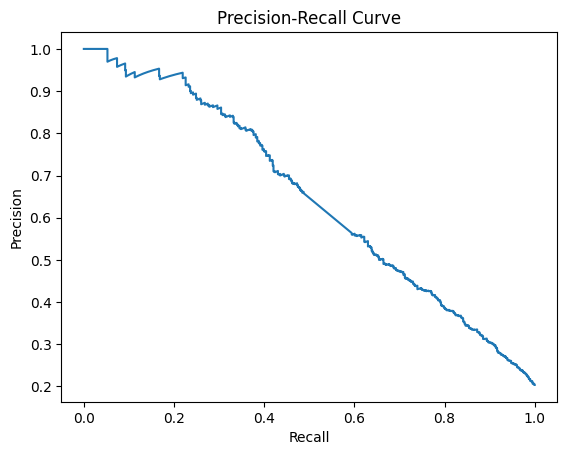

In [71]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

#### Threshold vs F1-score plot

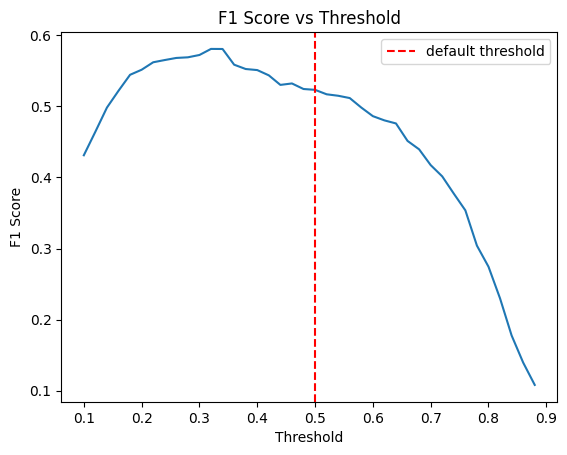

Best threshold: 0.32000000000000006, Best F1: 0.5807926829268293


In [72]:
from sklearn.metrics import f1_score

thresholds_range = np.arange(0.1, 0.9, 0.02)
f1_scores = [f1_score(y_test, (y_proba > t).astype(int)) for t in thresholds_range]

plt.plot(thresholds_range, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.axvline(x=0.5, color='red', linestyle='--', label='default threshold')
plt.legend()
plt.show()

best_threshold = thresholds_range[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold}, Best F1: {max(f1_scores)}")